# Vision Transformer Model for Retinal OCT Disease Classification

This notebook implements a Vision Transformer (ViT) model for multiclass classification of retinal OCT images from the Kermany2018 dataset.

The model is trained to classify retinal OCT images into four categories: CNV, DME, DRUSEN, and NORMAL. Unlike convolutional neural networks such as ResNet-50 and EfficientNet-B3, Vision Transformer divides each image into patches and uses self-attention mechanisms to capture global relationships across the image.

This experiment uses transfer learning with a pretrained ViT model, image resizing to 224×224 pixels, early stopping, model checkpointing, and evaluation metrics such as accuracy, precision, recall, F1-score, Macro F1-score, and a confusion matrix. The results will be compared against the CNN-based models to analyze predictive performance, generalization, computational cost, and convergence behavior.

In [3]:
!pip install -q transformers

In [6]:
!pip install -q timm

In [7]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import timm

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.10.0+cu128
CUDA disponible: True
Número de GPUs: 2
Device: cuda


In [13]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [14]:
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42
EPOCHS = 20
PATIENCE = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Clases:", class_names)
print("Número de clases:", NUM_CLASSES)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4
Train: 61284
Val: 7659
Test: 7664


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [30]:
from torch.utils.data import Subset
from collections import defaultdict

def create_balanced_subset(dataset, samples_per_class=80):
    class_indices = defaultdict(list)

    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    selected_indices = []

    for label, indices in class_indices.items():
        random.shuffle(indices)
        selected_indices.extend(indices[:samples_per_class])

    random.shuffle(selected_indices)
    return Subset(dataset, selected_indices)


small_train_dataset = create_balanced_subset(train_dataset, samples_per_class=80)
small_val_dataset = create_balanced_subset(val_dataset, samples_per_class=20)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Small train:", len(small_train_dataset))
print("Small val:", len(small_val_dataset))

Small train: 320
Small val: 80


## Create Vit Model

In [31]:
model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)

print(model.__class__.__name__)
print("Parámetros:", sum(p.numel() for p in model.parameters()))

VisionTransformer
Parámetros: 21667204


In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

## Training with early stopping

In [33]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    model_path,
    log_path
):
    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    
    best_val_loss = np.inf
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc = evaluate_one_epoch(
            model, val_loader, criterion, device
        )
        
        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )
        
        pd.DataFrame(history).to_csv(log_path, index=False)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("Best model saved.")
        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter}/{patience}")
            
        if patience_counter >= patience:
            print("Early stopping activated.")
            break
    
    end_time = time.time()
    training_time = end_time - start_time
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    return history, training_time

### Quick Test

In [34]:
history_small, small_training_time = train_model(
    model=model,
    train_loader=small_train_loader,
    val_loader=small_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=3,
    patience=2,
    model_path="vit_small_test_best_model.pth",
    log_path="vit_small_test_training_log.csv"
)

print(f"Tiempo prueba rápida: {small_training_time:.2f} segundos")
print(f"Tiempo prueba rápida: {small_training_time/60:.2f} minutos")

Epoch 1/3 | Train Loss: 1.3697 | Train Acc: 0.3750 | Val Loss: 1.0506 | Val Acc: 0.5375
Best model saved.
Epoch 2/3 | Train Loss: 0.8842 | Train Acc: 0.6594 | Val Loss: 0.8886 | Val Acc: 0.6250
Best model saved.
Epoch 3/3 | Train Loss: 0.5547 | Train Acc: 0.7875 | Val Loss: 0.6335 | Val Acc: 0.7625
Best model saved.
Tiempo prueba rápida: 11.95 segundos
Tiempo prueba rápida: 0.20 minutos


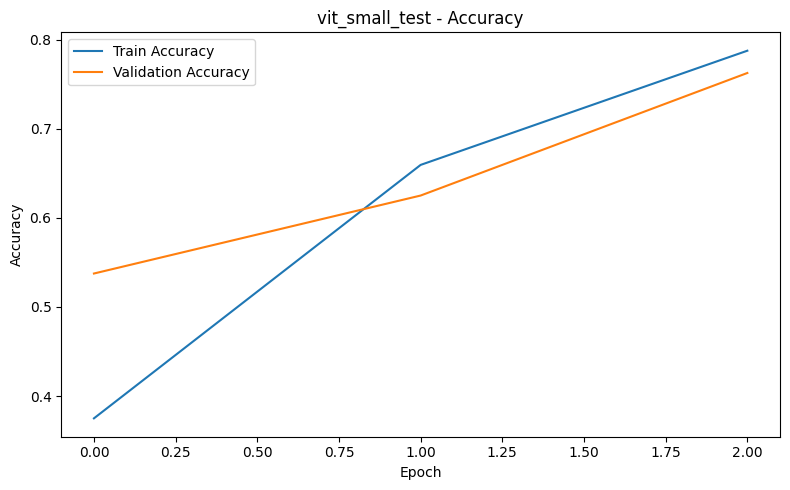

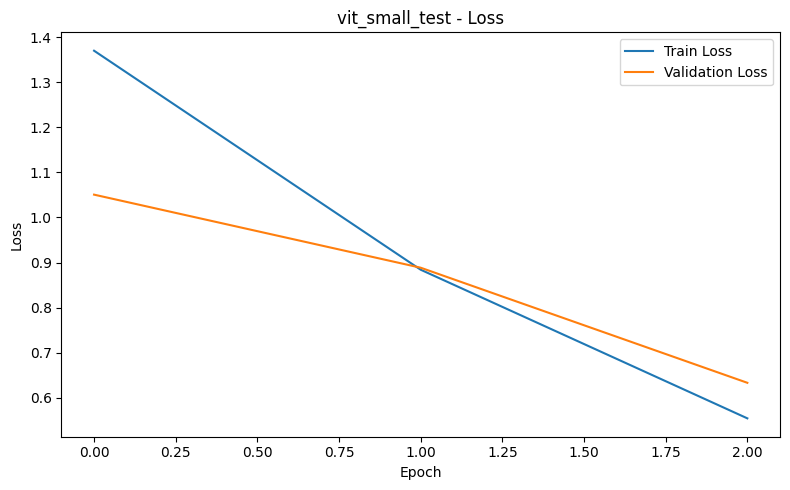

In [35]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history_small, "vit_small_test")

In [36]:
model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)

## Formal Training

In [37]:
history, training_time = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
    model_path="vit_best_model.pth",
    log_path="vit_training_log.csv"
)

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20 | Train Loss: 0.1900 | Train Acc: 0.9344 | Val Loss: 0.1401 | Val Acc: 0.9500
Best model saved.
Epoch 2/20 | Train Loss: 0.1282 | Train Acc: 0.9561 | Val Loss: 0.1133 | Val Acc: 0.9606
Best model saved.
Epoch 3/20 | Train Loss: 0.1048 | Train Acc: 0.9638 | Val Loss: 0.1179 | Val Acc: 0.9616
EarlyStopping counter: 1/5
Epoch 4/20 | Train Loss: 0.0881 | Train Acc: 0.9698 | Val Loss: 0.1041 | Val Acc: 0.9663
Best model saved.
Epoch 5/20 | Train Loss: 0.0774 | Train Acc: 0.9736 | Val Loss: 0.0984 | Val Acc: 0.9659
Best model saved.
Epoch 6/20 | Train Loss: 0.0681 | Train Acc: 0.9766 | Val Loss: 0.1027 | Val Acc: 0.9657
EarlyStopping counter: 1/5
Epoch 7/20 | Train Loss: 0.0594 | Train Acc: 0.9795 | Val Loss: 0.1266 | Val Acc: 0.9629
EarlyStopping counter: 2/5
Epoch 8/20 | Train Loss: 0.0546 | Train Acc: 0.9813 | Val Loss: 0.1037 | Val Acc: 0.9692
EarlyStopping counter: 3/5
Epoch 9/20 | Train Loss: 0.0506 | Train Acc: 0.9830 | Val Loss: 0.0956 | Val Acc: 0.9685
Best model saved.
E

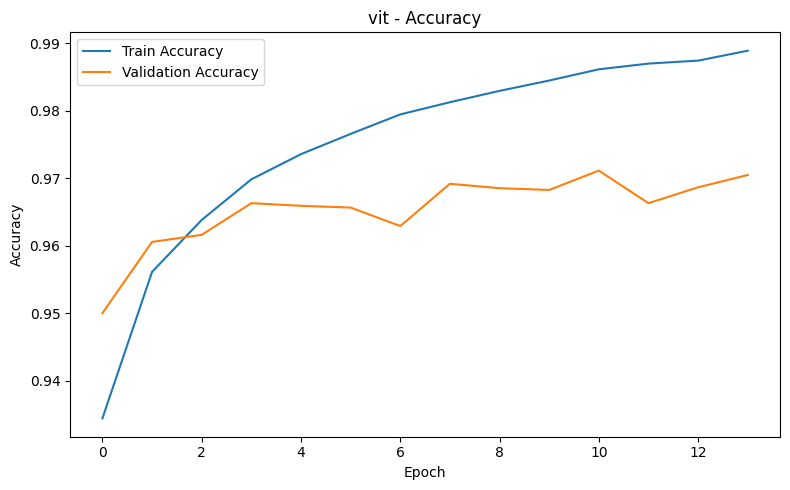

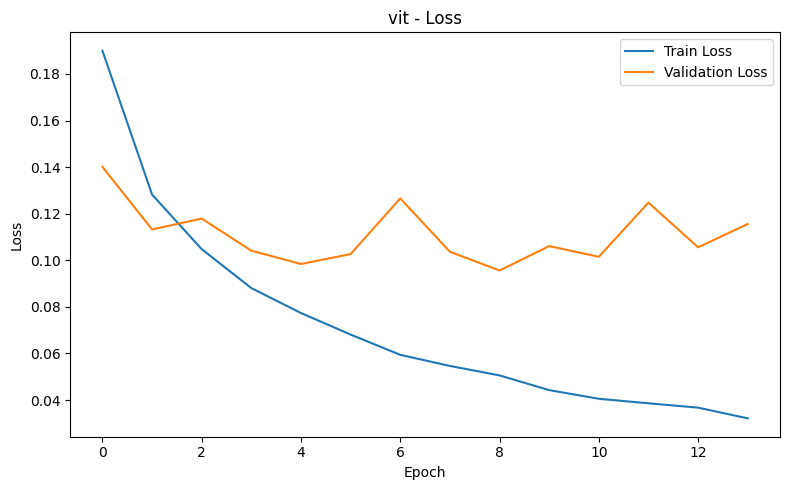

In [38]:
plot_training_curves(history, "vit")

In [39]:
def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred)


y_true, y_pred = get_predictions(model, test_loader, device)

In [40]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("vit_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.981341,0.980411,0.980876,3165.000000
DME,0.957195,0.956324,0.956759,1099.000000
DRUSEN,0.898196,0.890166,0.894163,783.000000
NORMAL,0.972222,0.976309,0.974261,2617.000000
accuracy,0.966336,0.966336,0.966336,0.966336
macro avg,0.952238,0.950802,0.951515,7664.000000
weighted avg,0.966270,0.966336,0.966300,7664.000000


In [41]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3165
         DME       0.96      0.96      0.96      1099
      DRUSEN       0.90      0.89      0.89       783
      NORMAL       0.97      0.98      0.97      2617

    accuracy                           0.97      7664
   macro avg       0.95      0.95      0.95      7664
weighted avg       0.97      0.97      0.97      7664



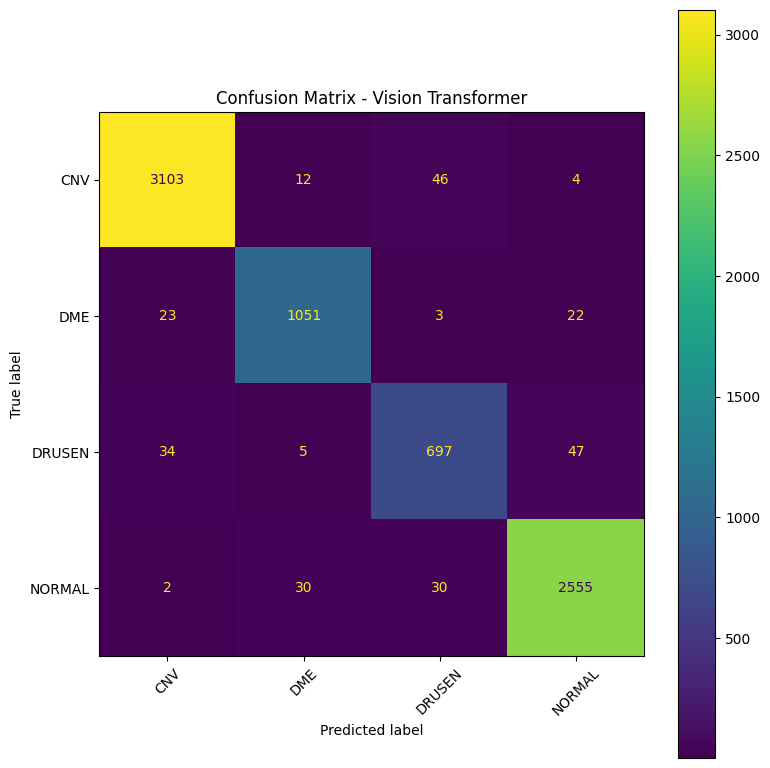

In [42]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Vision Transformer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("vit_confusion_matrix.png", dpi=300)
plt.show()

In [43]:
metrics = {
    "model": "Vision Transformer",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("vit_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,Vision Transformer,0.966336,0.952238,0.950802,0.951515,0.96627,0.966336,0.9663,9191.638943,153.193982,14


In [44]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

params_summary = pd.DataFrame([{
    "model": "Vision Transformer",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("vit_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,Vision Transformer,21667204,21667204,0
